In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [31]:
df_l1 = pd.read_csv('/content/l1-total-malware.csv')
df_l2 = pd.read_csv('/content/l2-total-malware.csv')
df_l3 = pd.read_csv('/content/l3-malware.csv')
df_total = pd.read_csv('/content/Total-48h-Augmentation.csv')


In [32]:
df_l1 = df_l1[df_l1['Label'] == 'NonDoH']
df_l1 = df_l1.sample(n=20000, random_state=42)

In [33]:
df_l1 = df_l1[df_l1['Label'] == 'NonDoH']
c1 = df_total[df_total['Label'] == 'dnstt']
c2 = df_total[df_total['Label'] == 'tuns']
c3 = df_total[df_total['Label'] == 'tcp-over-dns']

c1 = c1.sample(n=3000, random_state=42)
c2 = c2.sample(n=3000, random_state=42)
c3 = c3.sample(n=3000, random_state=42)

df_total = pd.concat([c1, c2, c3])

In [34]:
common_cols = df_l1.columns.intersection(df_l2.columns)
common_cols = df_l2.columns.intersection(df_l3.columns)
common_cols = common_cols.intersection(df_total.columns)

df_l2 = df_l2[common_cols]
df_l3 = df_l3[common_cols]
df_total = df_total[common_cols]

In [35]:
def plot_labels(df, title, label_col="Label"):
    counts = df[label_col].value_counts().sort_index()
    plt.figure(figsize=(10, 6))
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='viridis', legend=False)
    plt.title(title)
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

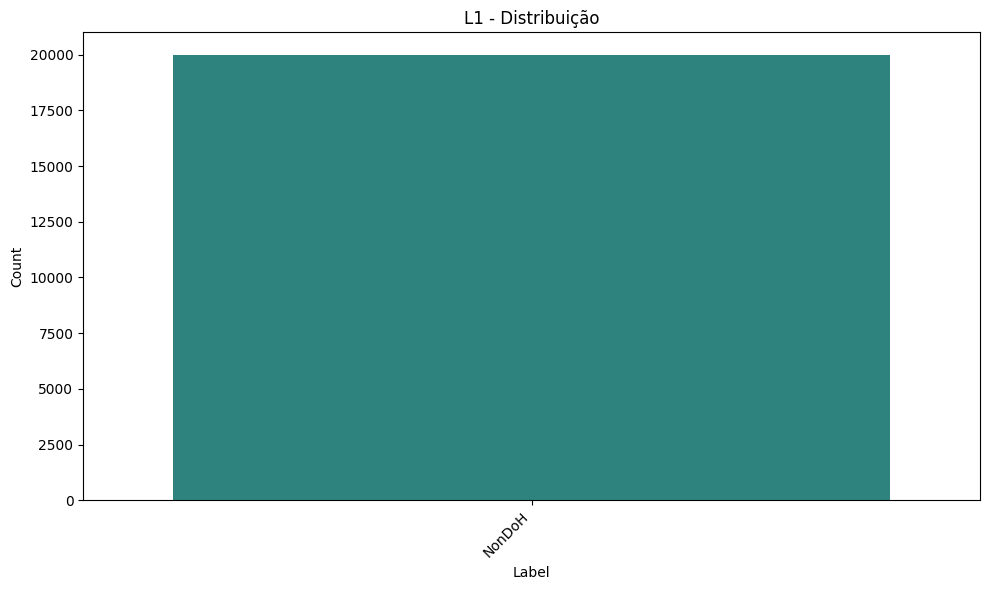

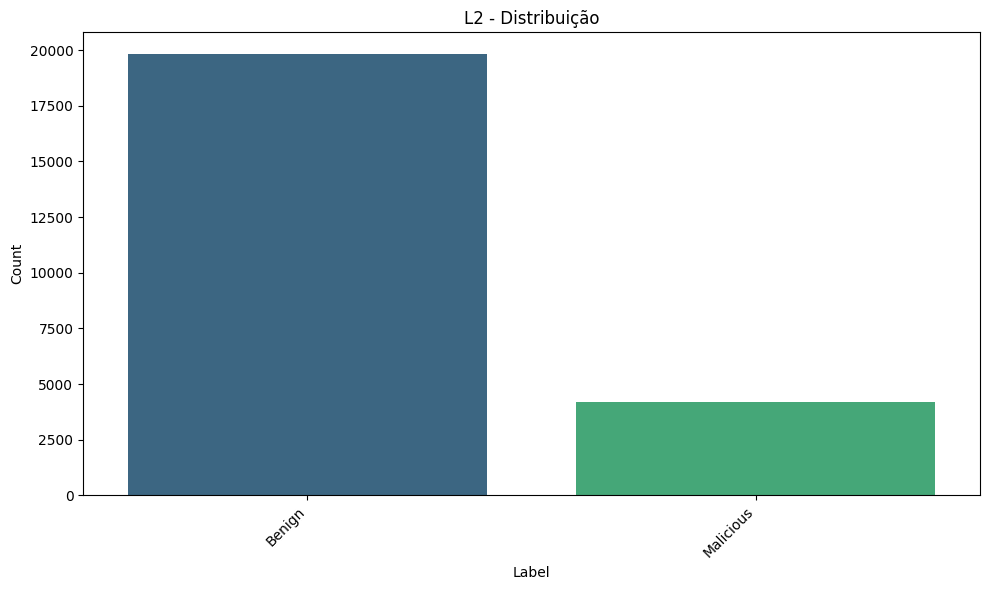

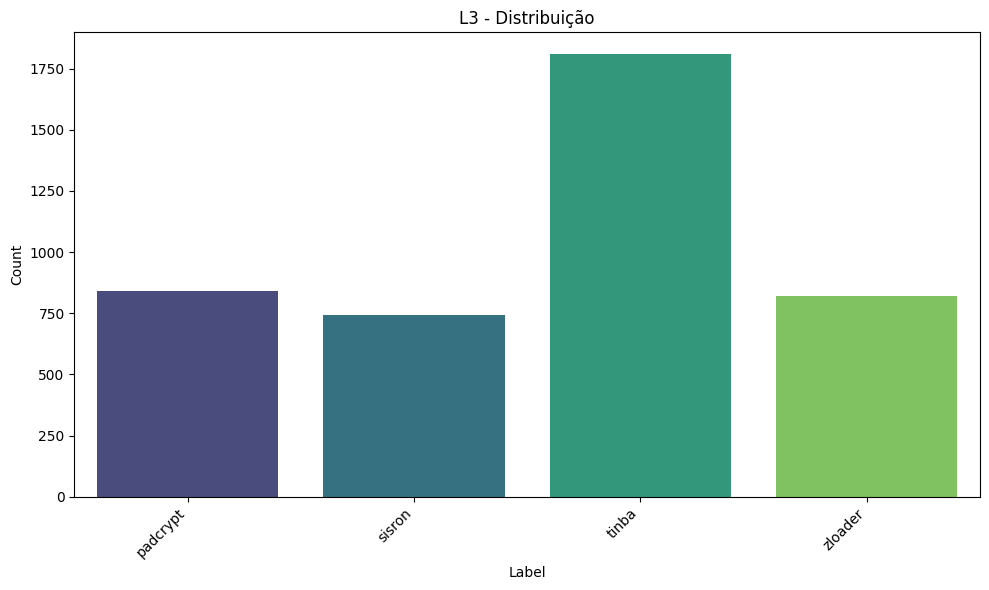

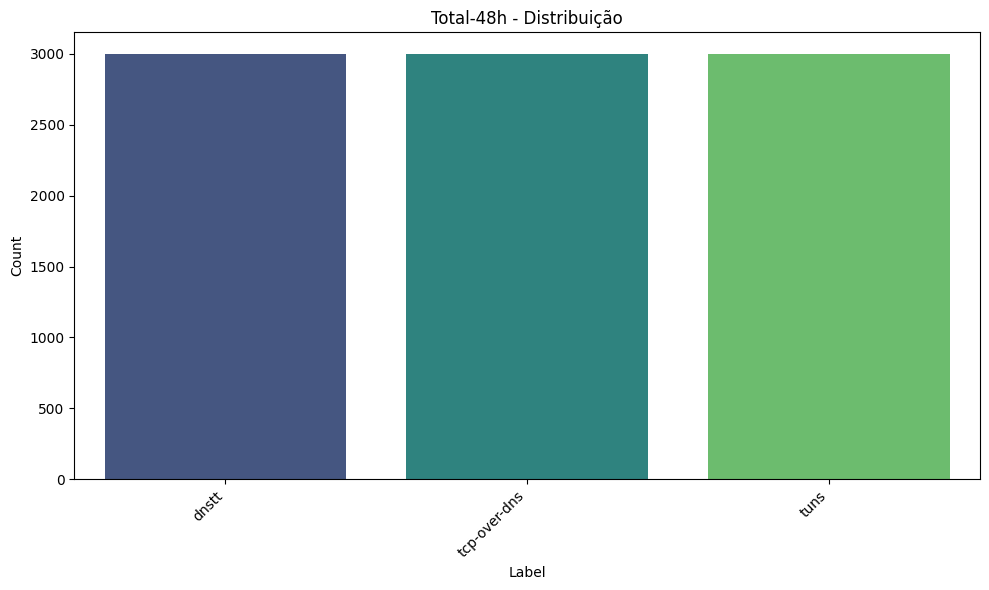

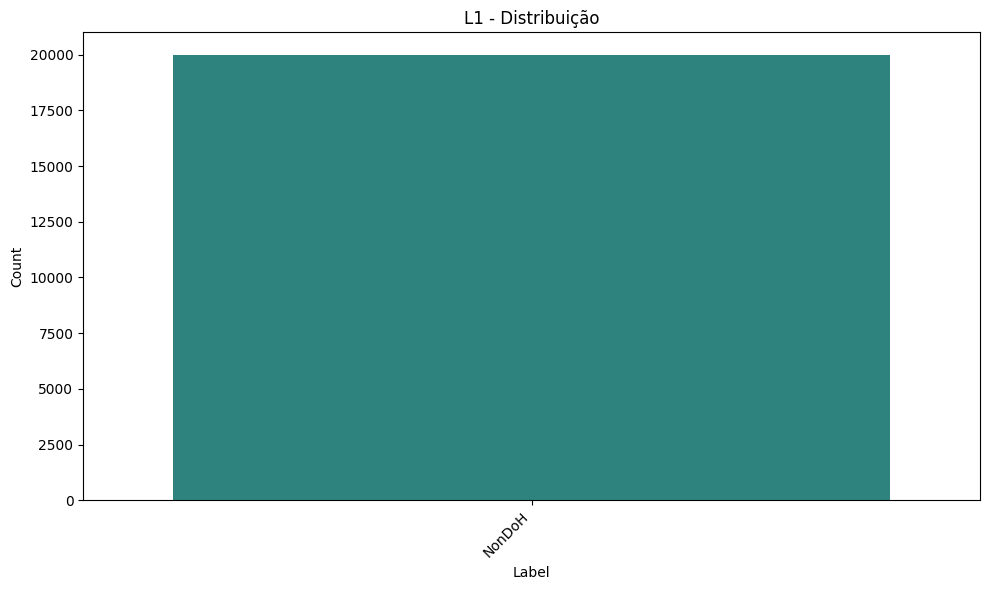

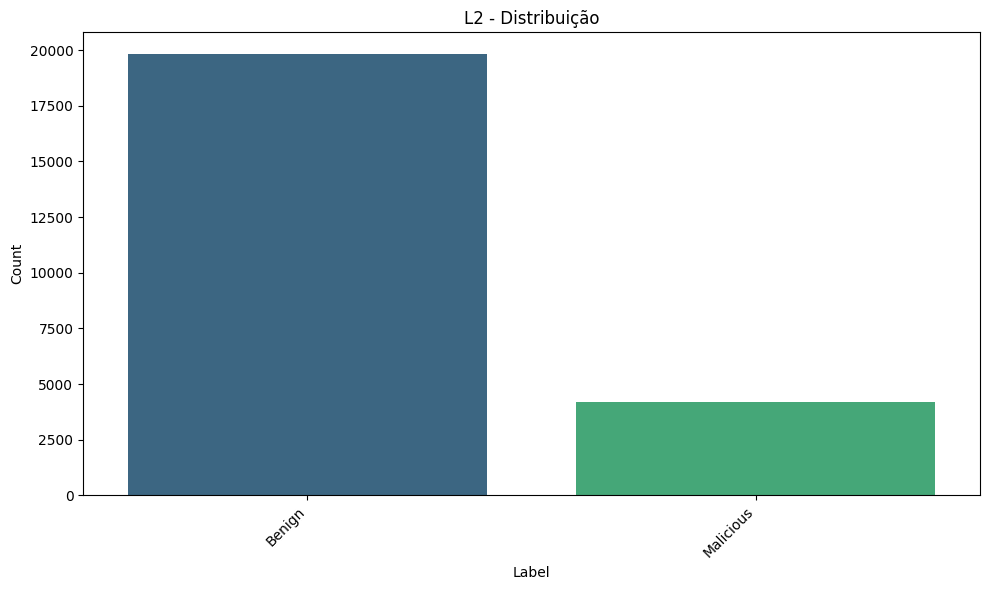

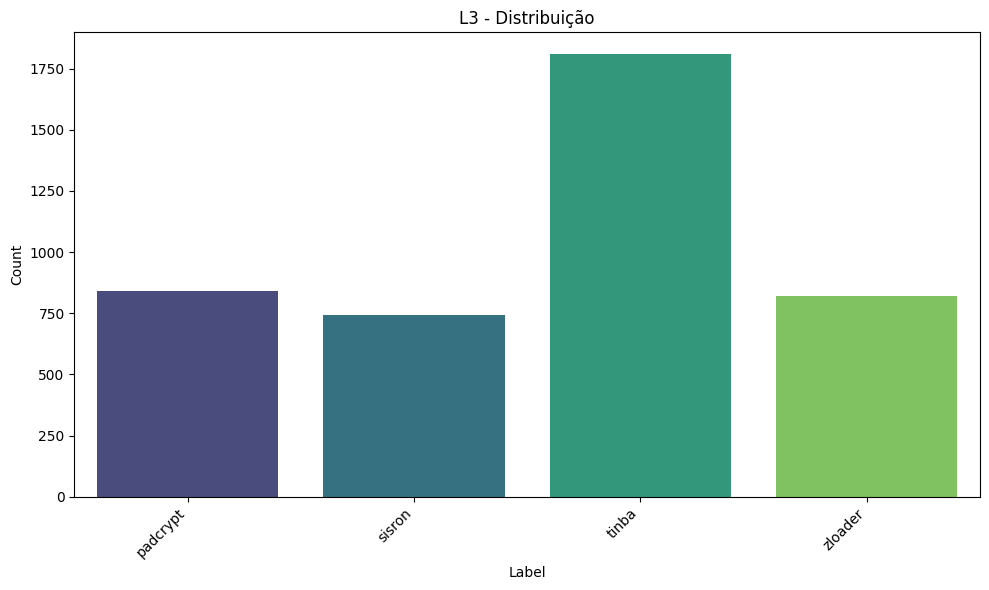

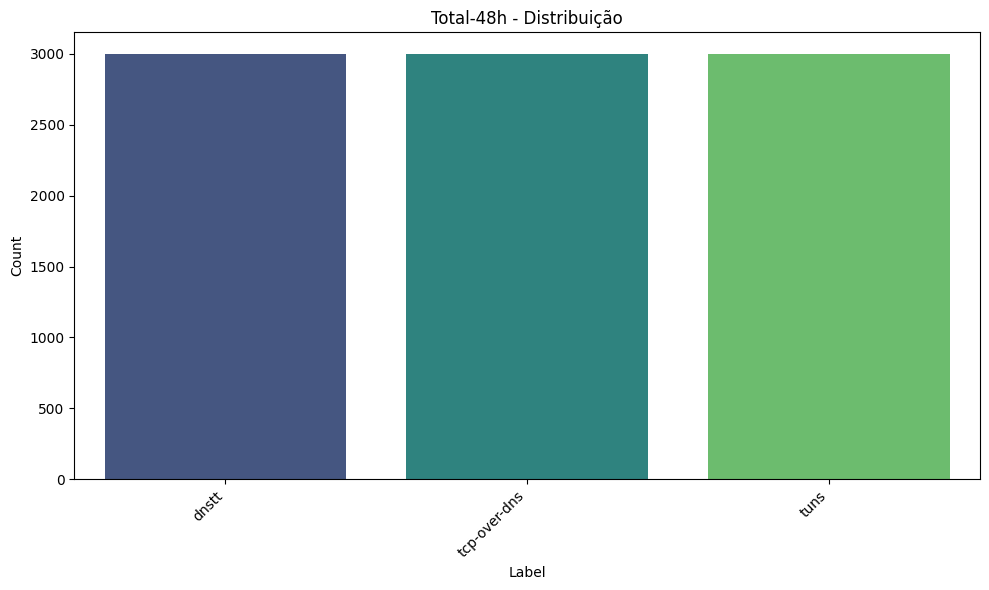

In [36]:
plot_labels(df_l1, "L1 - Distribuição")
plot_labels(df_l2, "L2 - Distribuição")
plot_labels(df_l3, "L3 - Distribuição")
plot_labels(df_total, "Total-48h - Distribuição")

In [37]:
df_concat = pd.concat([df_l1, df_l2, df_l3, df_total], ignore_index=True)

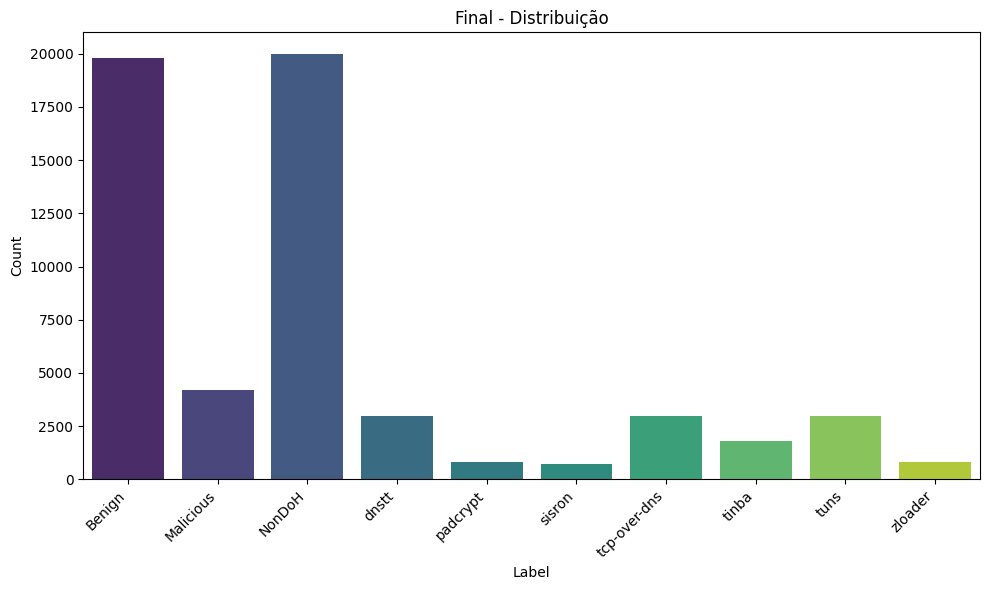

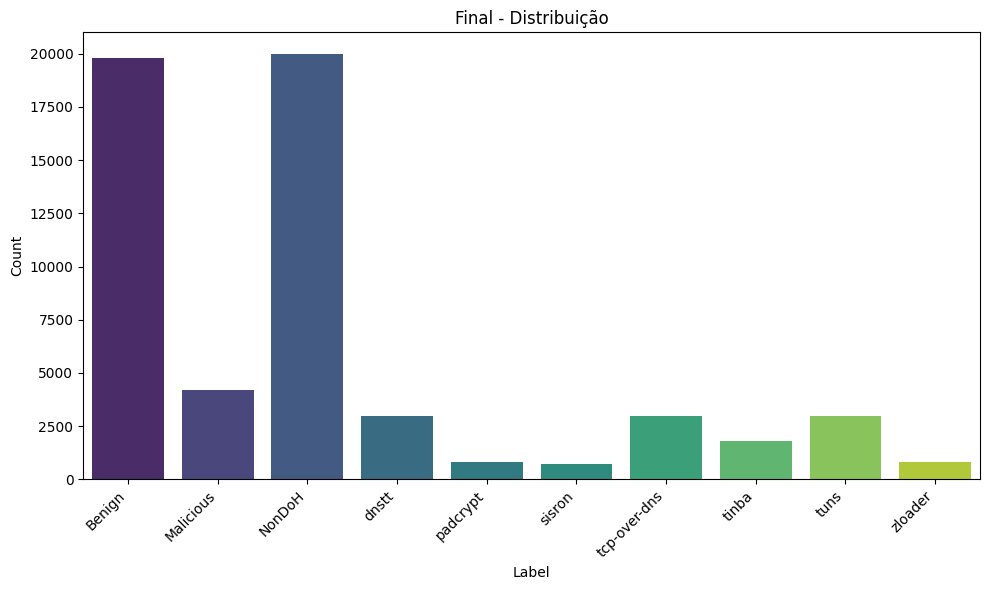

In [38]:
plot_labels(df_concat, "Final - Distribuição")

In [39]:
df_bin = df_concat.copy()
df_bin['Label'] = df_bin['Label'].map({
    'Benign': 0,
    'NonDoH': 1,
    'Malicious': 2,
    'padcrypt': 2,
    'sisron': 2,
    'tinba': 2,
    'zloader' : 2,
    'dnstt' : 2,
    'tuns' : 2,
    'tcp-over-dns' : 2,
})

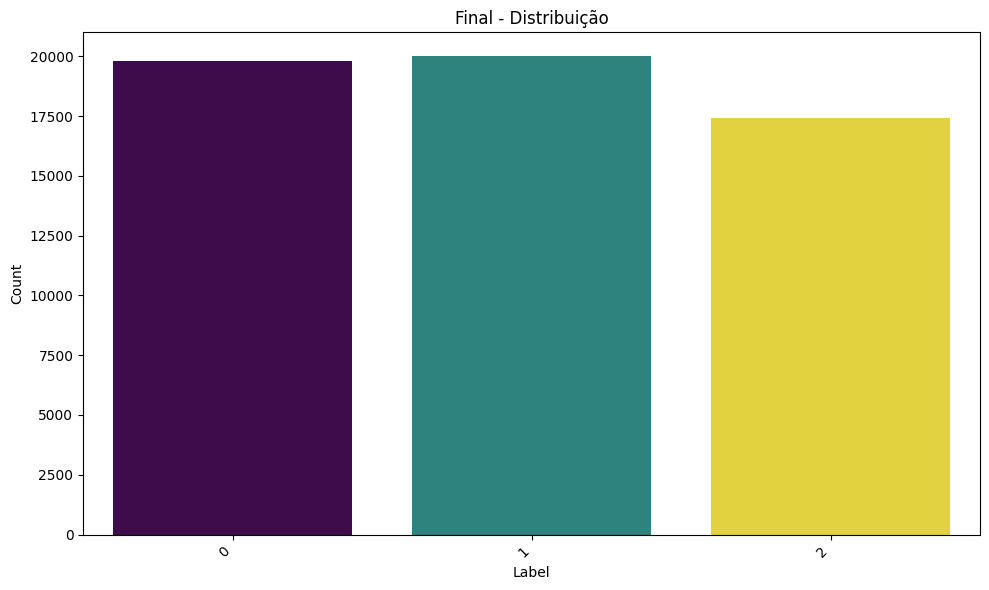

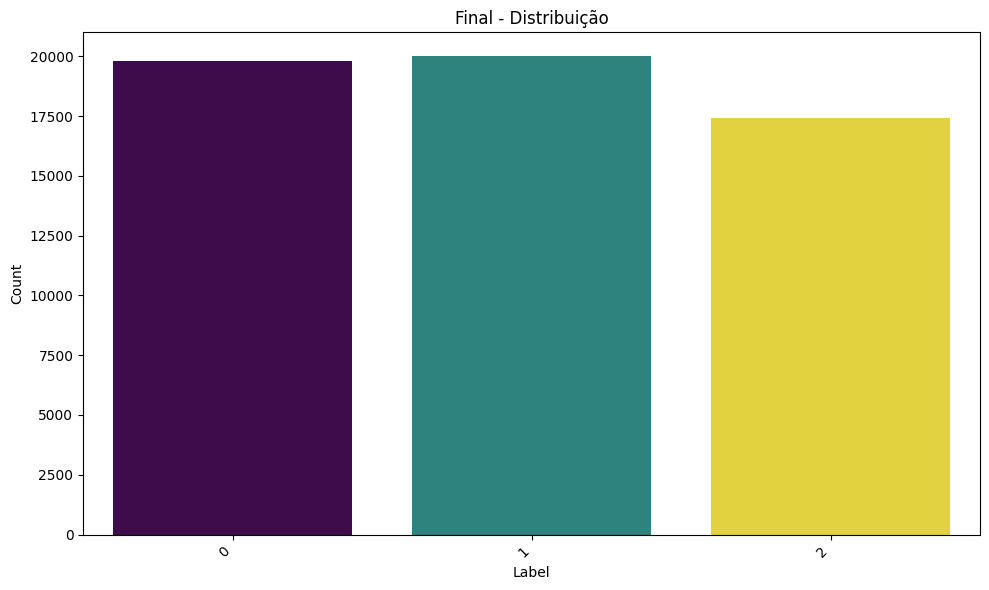

In [40]:
plot_labels(df_bin, "Final - Distribuição")

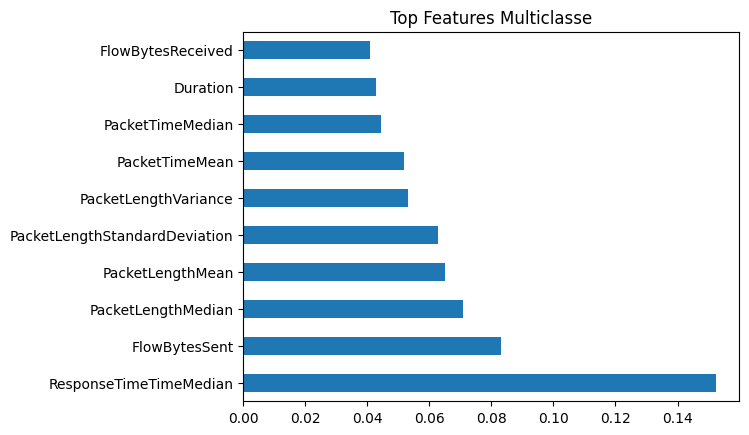

In [12]:
X = df_bin.select_dtypes(include=['number']).drop('Label', axis=1)
y = df_bin['Label']

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)

importances.nlargest(10).plot(kind='barh', title='Top Features Multiclasse')
plt.show()

In [13]:
print("Distribuição final:")
print(df_bin['Label'].value_counts())

Distribuição final:
Label
1    20000
0    19807
2    17424
Name: count, dtype: int64


In [14]:
X = df_bin.drop('Label', axis=1)
y = df_bin['Label']

print("Shape:")
print("X:", X.shape)
print("y:", y.shape)

print("\nDistribuição original:")
print(y.value_counts())

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("\n depois do split")
print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

print("\nDistribuição treino:")
print(y_train.value_counts())

print("\nDistribuição validação:")
print(y_val.value_counts())

print("\nDistribuição teste:")
print(y_test.value_counts())

Shape:
X: (57231, 34)
y: (57231,)

Distribuição original:
Label
1    20000
0    19807
2    17424
Name: count, dtype: int64

 depois do split
Treino: (40061, 34)
Validação: (8585, 34)
Teste: (8585, 34)

Distribuição treino:
Label
1    14000
0    13865
2    12196
Name: count, dtype: int64

Distribuição validação:
Label
1    3000
0    2971
2    2614
Name: count, dtype: int64

Distribuição teste:
Label
1    3000
0    2971
2    2614
Name: count, dtype: int64


In [15]:
from sklearn.preprocessing import StandardScaler

print("\nFeats numericas:")

X_train = X_train.select_dtypes(include=['number'])
X_val = X_val[X_train.columns]
X_test = X_test[X_train.columns]

print("Novas colunas:")
print(X_train.columns)

#Normalizando
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nDepois da normalização:")
print("Treino:", X_train_scaled.shape)


Feats numericas:
Novas colunas:
Index(['SourcePort', 'DestinationPort', 'Duration', 'FlowBytesSent',
       'FlowSentRate', 'FlowBytesReceived', 'FlowReceivedRate',
       'PacketLengthVariance', 'PacketLengthStandardDeviation',
       'PacketLengthMean', 'PacketLengthMedian', 'PacketLengthMode',
       'PacketLengthSkewFromMedian', 'PacketLengthSkewFromMode',
       'PacketLengthCoefficientofVariation', 'PacketTimeVariance',
       'PacketTimeStandardDeviation', 'PacketTimeMean', 'PacketTimeMedian',
       'PacketTimeMode', 'PacketTimeSkewFromMedian', 'PacketTimeSkewFromMode',
       'PacketTimeCoefficientofVariation', 'ResponseTimeTimeVariance',
       'ResponseTimeTimeStandardDeviation', 'ResponseTimeTimeMean',
       'ResponseTimeTimeMedian', 'ResponseTimeTimeMode',
       'ResponseTimeTimeSkewFromMedian', 'ResponseTimeTimeSkewFromMode',
       'ResponseTimeTimeCoefficientofVariation'],
      dtype='object')

Depois da normalização:
Treino: (40061, 31)


In [16]:
print("\n=== Modelo com TODAS as features ===")

model_all = RandomForestClassifier(random_state=42)
model_all.fit(X_train_scaled, y_train)

y_pred_all = model_all.predict(X_test_scaled)

from sklearn.metrics import classification_report

print("Resultados com todas as features:")
print(classification_report(y_test, y_pred_all))


=== Modelo com TODAS as features ===
Resultados com todas as features:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2971
           1       0.97      0.97      0.97      3000
           2       1.00      1.00      1.00      2614

    accuracy                           0.98      8585
   macro avg       0.98      0.98      0.98      8585
weighted avg       0.98      0.98      0.98      8585



In [17]:
print("\n=== Selecionando TOP features ===")

importances = pd.Series(model_all.feature_importances_, index=X_train.columns)

top_features = importances.nlargest(10).index

print("Top features:")
print(top_features)


=== Selecionando TOP features ===
Top features:
Index(['ResponseTimeTimeMedian', 'FlowBytesSent', 'PacketLengthMean',
       'PacketLengthVariance', 'PacketTimeMedian', 'PacketLengthMedian',
       'PacketLengthMode', 'PacketTimeMean', 'FlowBytesReceived',
       'PacketLengthStandardDeviation'],
      dtype='object')


In [18]:
print("\n=== Modelo com TOP features ===")

# filtrar
X_train_top = X_train[top_features]
X_val_top = X_val[top_features]
X_test_top = X_test[top_features]

# normalizar
scaler = StandardScaler()

X_train_top = scaler.fit_transform(X_train_top)
X_test_top = scaler.transform(X_test_top)

# treinar
model_top = RandomForestClassifier(random_state=42)
model_top.fit(X_train_top, y_train)

# prever
y_pred_top = model_top.predict(X_test_top)

print("Resultados com TOP features:")
print(classification_report(y_test, y_pred_top))


=== Modelo com TOP features ===
Resultados com TOP features:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2971
           1       0.97      0.97      0.97      3000
           2       1.00      1.00      1.00      2614

    accuracy                           0.98      8585
   macro avg       0.98      0.98      0.98      8585
weighted avg       0.98      0.98      0.98      8585



In [19]:
y_shuffled = np.random.permutation(y_train)

model_test = RandomForestClassifier(random_state=42)
model_test.fit(X_train_scaled, y_shuffled)

y_pred_test = model_test.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

print("Accuracy com labels embaralhados:")
print(accuracy_score(y_test, y_pred_test))

Accuracy com labels embaralhados:
0.36086196854979613


In [20]:
print("\n=== Verificando colunas suspeitas ===")

for col in X.columns:
    if 'label' in col.lower():
        print("Possível vazamento:", col)


=== Verificando colunas suspeitas ===


In [21]:
print("\n=== Overfitting check ===")

print("Treino:", model_all.score(X_train_scaled, y_train))
print("Teste:", model_all.score(X_test_scaled, y_test))


=== Overfitting check ===
Treino: 1.0
Teste: 0.9785672684915551


In [22]:
print("\n=== TESTE SEM TOP FEATURES ===")

X_train_drop = X_train.drop(columns=top_features)
X_test_drop = X_test.drop(columns=top_features)

scaler = StandardScaler()
X_train_drop = scaler.fit_transform(X_train_drop)
X_test_drop = scaler.transform(X_test_drop)

model_drop = RandomForestClassifier(random_state=42)
model_drop.fit(X_train_drop, y_train)

y_pred_drop = model_drop.predict(X_test_drop)

print(classification_report(y_test, y_pred_drop))


=== TESTE SEM TOP FEATURES ===
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      2971
           1       0.96      0.97      0.97      3000
           2       1.00      1.00      1.00      2614

    accuracy                           0.98      8585
   macro avg       0.98      0.98      0.98      8585
weighted avg       0.98      0.98      0.98      8585



In [23]:
print("\n=== SHAP - MODELO COMPLETO ===")

import shap

# criar explicador
explainer_full = shap.TreeExplainer(model_all)

# calcular valores shap (classe 1 se binário)
shap_values_full = explainer_full.shap_values(X_test_scaled)

print("SHAP calculado para modelo completo")
print("Shape SHAP:", len(shap_values_full), "classes")


=== SHAP - MODELO COMPLETO ===
SHAP calculado para modelo completo
Shape SHAP: 8585 classes


Matriz:
[[2870   99    2]
 [  83 2917    0]
 [   0    0 2614]]


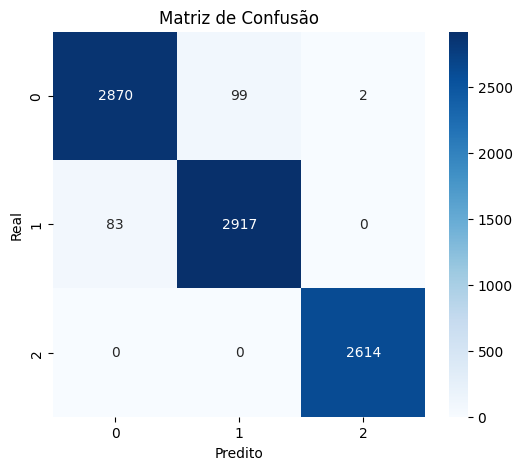

In [24]:
y_test_pred = model_all.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_test_pred)

print("Matriz:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()


=== Distribuição da feature: FlowSentRate ===


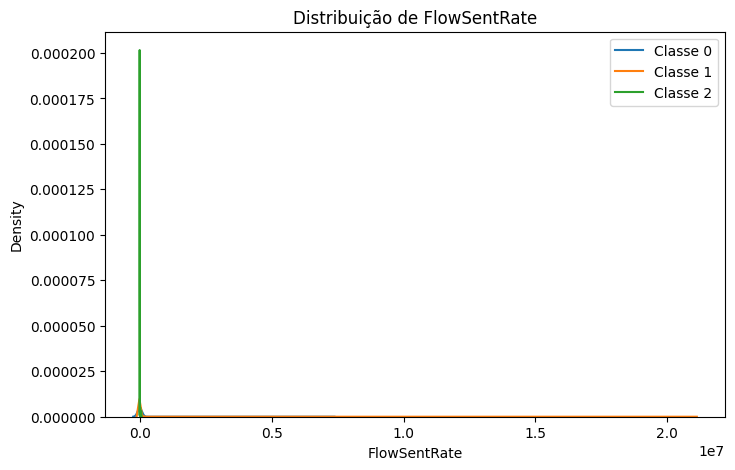

In [25]:
feature = 'FlowSentRate'

print(f"\n=== Distribuição da feature: {feature} ===")

plt.figure(figsize=(8,5))

for label in sorted(y.unique()):
    sns.kdeplot(
        X[feature][y == label],
        label=f'Classe {label}'
    )

plt.legend()
plt.title(f"Distribuição de {feature}")
plt.show()


=== Boxplot: FlowSentRate vs Classe ===


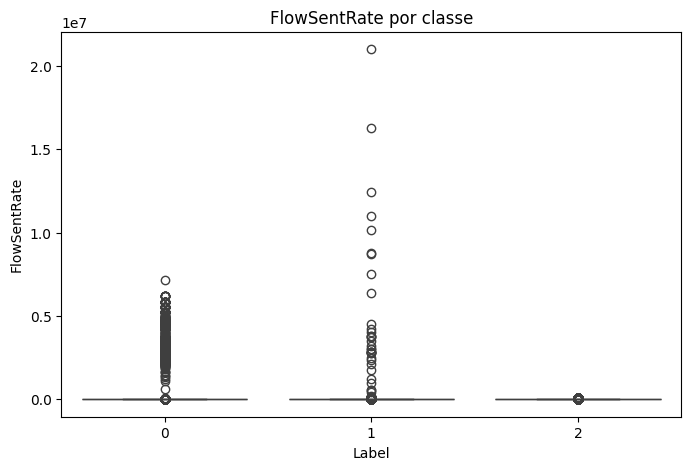

In [26]:
feature = 'FlowSentRate'

print(f"\n=== Boxplot: {feature} vs Classe ===")

plt.figure(figsize=(8,5))
sns.boxplot(x=y, y=X[feature])
plt.title(f"{feature} por classe")
plt.show()

In [27]:
print("\nsó com FlowSentRate")

X_train_1 = X_train[['FlowSentRate']]
X_test_1 = X_test[['FlowSentRate']]

from sklearn.ensemble import RandomForestClassifier

model_1 = RandomForestClassifier()
model_1.fit(X_train_1, y_train)

y_pred_1 = model_1.predict(X_test_1)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_1))


só com FlowSentRate
              precision    recall  f1-score   support

           0       0.67      0.64      0.65      2971
           1       0.67      0.64      0.66      3000
           2       0.84      0.92      0.88      2614

    accuracy                           0.73      8585
   macro avg       0.73      0.74      0.73      8585
weighted avg       0.72      0.73      0.72      8585




=== Visualização 2D ===


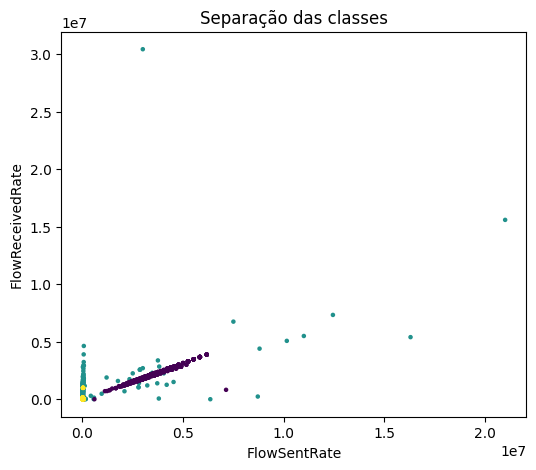

In [28]:
print("\n=== Visualização 2D ===")

plt.figure(figsize=(6,5))

plt.scatter(
    X['FlowSentRate'],
    X['FlowReceivedRate'],
    c=y,
    cmap='viridis',
    s=5
)

plt.xlabel('FlowSentRate')
plt.ylabel('FlowReceivedRate')
plt.title('Separação das classes')
plt.show()

Gerando SHAP Summary Plot Global...


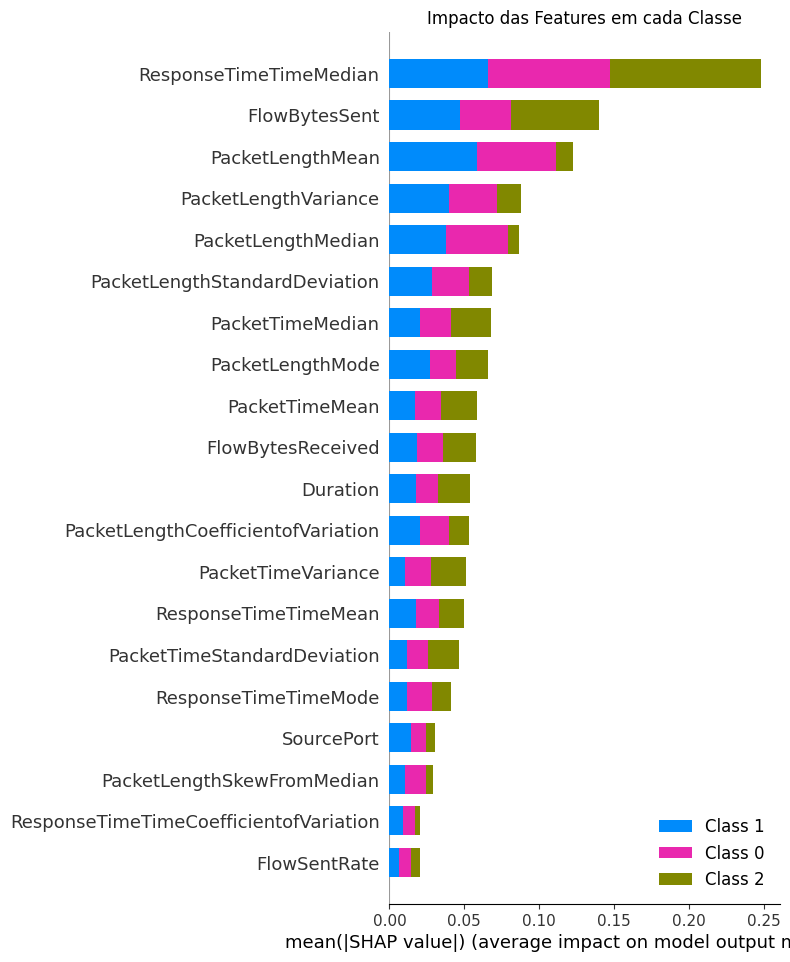

Gerando SHAP Bar Plot...


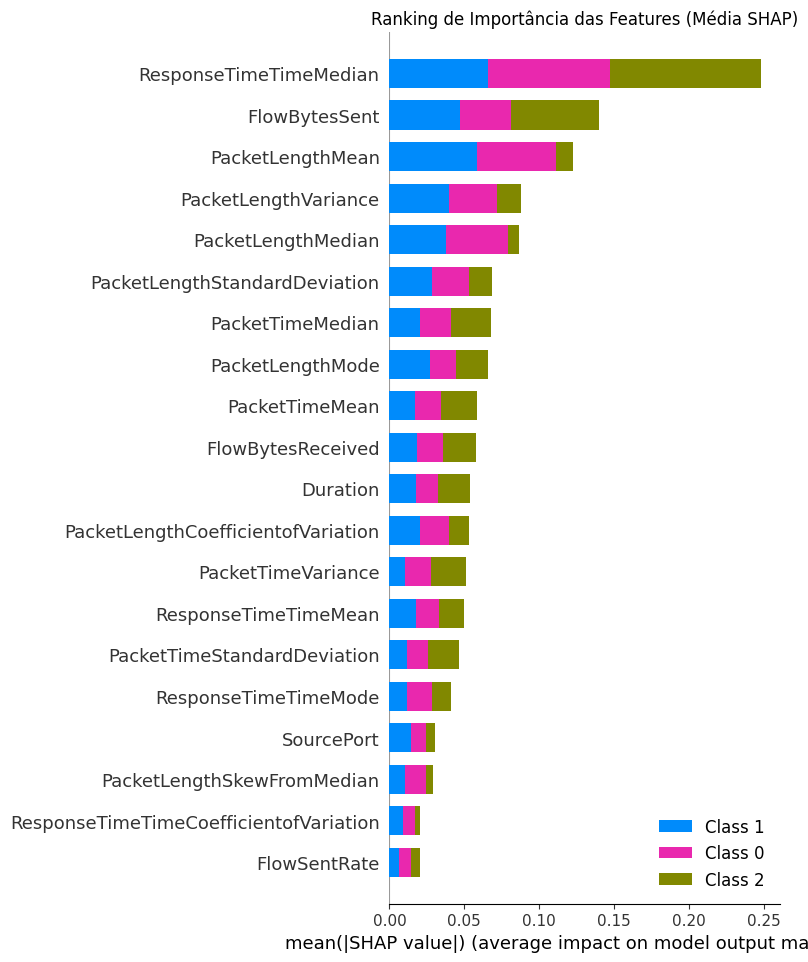

Gerando Beeswarm Plot para a Classe 2 (Malicioso)...


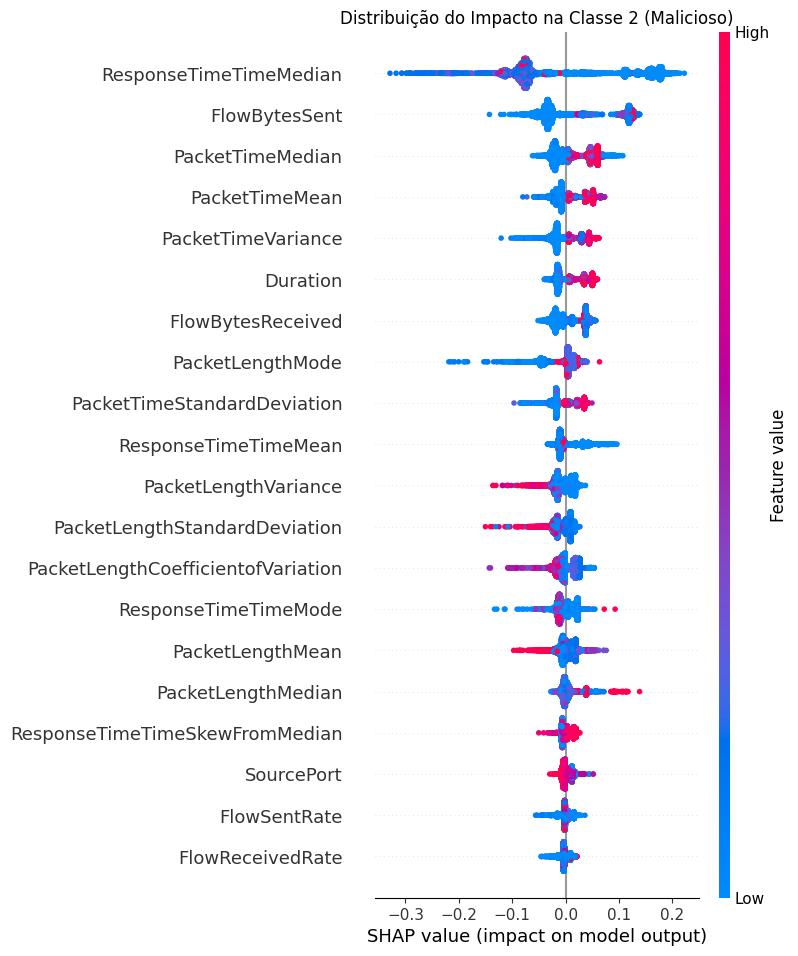

In [29]:
import shap
import matplotlib.pyplot as plt
import numpy as np


if isinstance(shap_values_full, np.ndarray) and shap_values_full.ndim == 3:
    shap_list = [shap_values_full[:, :, i] for i in range(shap_values_full.shape[2])]
else:
    shap_list = shap_values_full

print("Gerando SHAP Summary Plot Global...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_list, X_test_scaled, feature_names=X_train.columns, show=False)
plt.title("Impacto das Features em cada Classe")
plt.show()

print("Gerando SHAP Bar Plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_list, X_test_scaled, feature_names=X_train.columns, plot_type="bar", show=False)
plt.title("Ranking de Importância das Features (Média SHAP)")
plt.show()

print("Gerando Beeswarm Plot para a Classe 2 (Malicioso)...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_list[2], X_test_scaled, feature_names=X_train.columns, show=False)
plt.title("Distribuição do Impacto na Classe 2 (Malicioso)")
plt.show()